In [72]:
import sys
# import os
# from os.path import join
# import glob
# from copy import deepcopy

import numpy as np
import pandas as pd
from pandas.testing import assert_frame_equal
from matplotlib import pyplot as plt
from scipy import stats
from IPython.display import display, clear_output
# from tqdm import tqdm

sys.path.insert(0, "../../ABC-SN/code")
# import abcsn_config
# import abcsn_training
# import data_degrading as dg
# import data_plotting as dplt
# import data_preparation as dp
# import preprocessing

sys.path.insert(0, "../code")
import measure_signal as ms
from unpack_dataset import unpack_dataset

# from icecream import ic
# from importlib import reload

rng = np.random.default_rng(1415)

In [2]:
file_dataset_SNRinfo = "../data/forSNR/dataset_SNRinfo.parquet"
file_signal_only = "../data/forSNR/signal.parquet"
file_noise_only = "../data/forSNR/noise.parquet"

In [3]:
df_dataset = pd.read_parquet(file_dataset_SNRinfo)
df_signal = pd.read_parquet(file_signal_only)
df_noise = pd.read_parquet(file_noise_only)

In [31]:
wvl, spectra, df_meta = unpack_dataset(df_dataset)
_, spectra_signal, df_meta_signal = unpack_dataset(df_signal)
_, spectra_noise, df_meta_noise = unpack_dataset(df_noise)
assert_frame_equal(df_meta_signal, df_meta_noise)

num_spectra, num_wvl = spectra.shape

In [5]:
wvl.shape, spectra.shape, df_meta.shape

((1024,), (3574, 1024), (3574, 20))

In [6]:
spectra_signal.shape, df_meta_signal.shape

((3574, 1024), (3574, 23))

In [7]:
spectra_noise.shape, df_meta_noise.shape

((3574, 1024), (3574, 23))

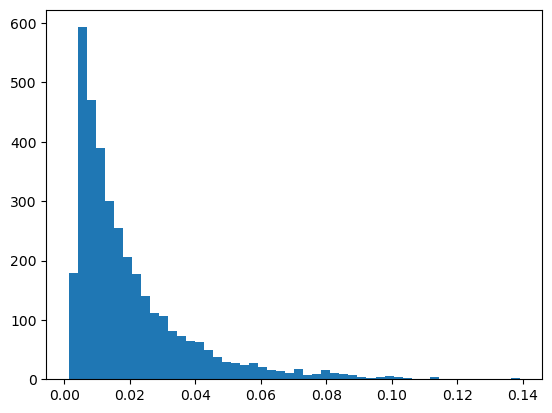

In [64]:
plt.hist(df_meta_signal["N (SNR)"], bins=50);
# plt.yscale("log")
# plt.xscale("log")

In [80]:
new_SNR = 25
new_N = (df_meta_signal["S (SNR)"] / new_SNR).to_numpy()
new_N_arr = np.full((num_spectra, num_wvl), new_N[..., np.newaxis])
new_noise = stats.norm.rvs(loc=0, scale=new_N_arr, random_state=rng)
new_spectra = spectra_signal + new_noise
# new_spectra = np.clip(spectra_signal + new_noise, 0, 1)


In [89]:
rng.integers(0, high=num_spectra, size=Nonex)

1992

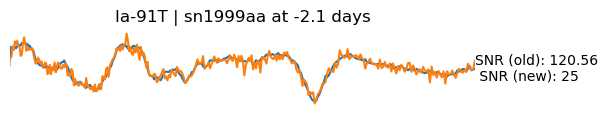

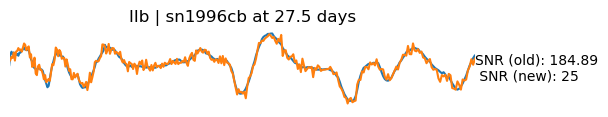

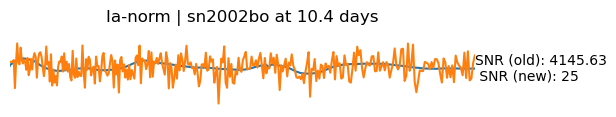

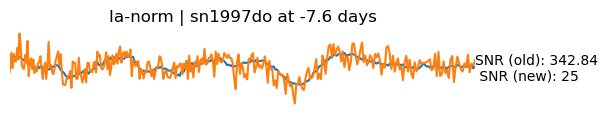

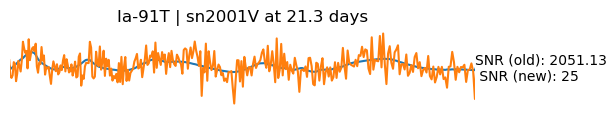

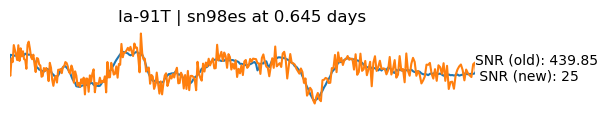

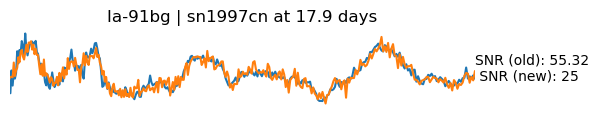

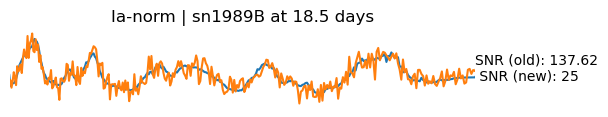

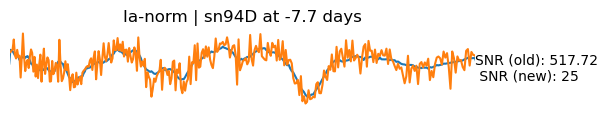

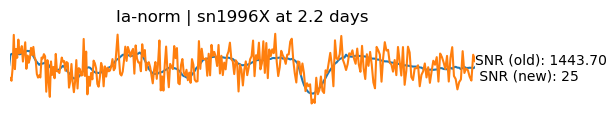

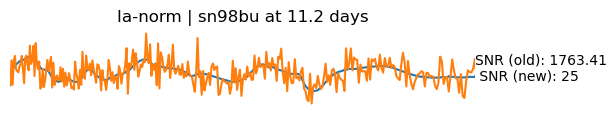

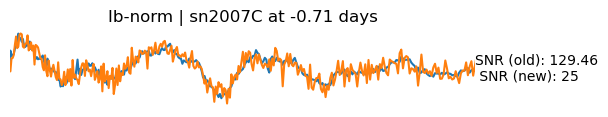

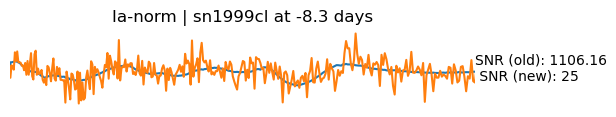

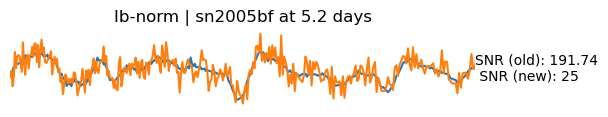

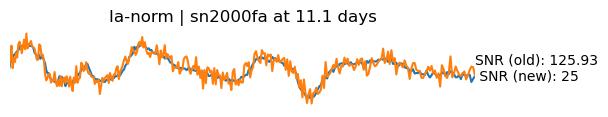

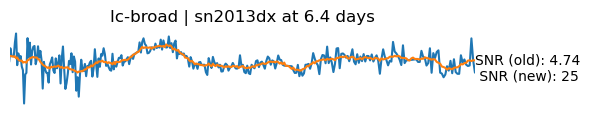

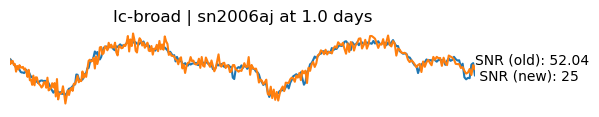

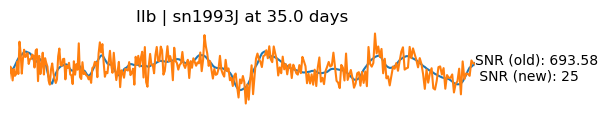

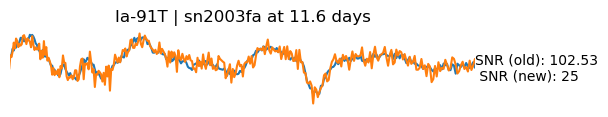

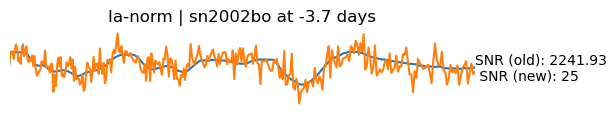

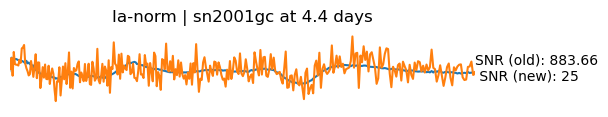

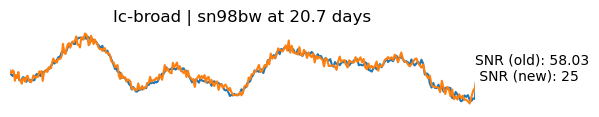

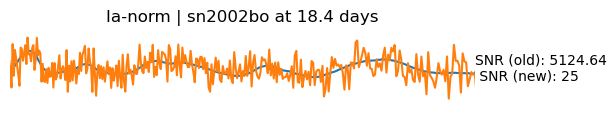

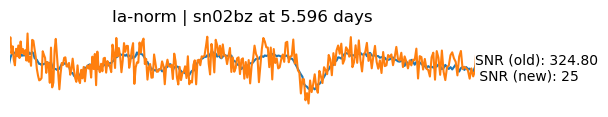

In [92]:
j = 1
while True:
    i = rng.integers(0, high=num_spectra)
# for i in range(num_spectra):
    spectrum_i = spectra[i]
    signal_i = spectra_signal[i]
    noise_i = spectra_noise[i]
    new_noise_i = new_noise[i]
    new_spectrum_i = new_spectra[i]
    metadata_i = df_meta_signal.iloc[i]

    spec_min = np.min(spectrum_i)
    spec_max = np.max(spectrum_i)
    spectrum_i -= spec_min
    spectrum_i /= (spec_max - spec_min)
    assert np.max(spectrum_i) == 1
    assert np.min(spectrum_i) == 0
    
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 1))

    ax.set_title(f"{metadata_i['SN Subtype']} | {metadata_i['SN Name']} at {metadata_i['Spectral Phase']} days")
    ax.axis("off")
    ax.set_xlim((4500, 7000))
    ax.plot(wvl, spectrum_i)
    ax.plot(wvl, new_spectrum_i)
    
    vertical_midpoint = np.mean(ax.get_ylim())
    horizontal_text_location = ax.get_xlim()[1]
    ax.text(
        horizontal_text_location, vertical_midpoint,
        f"SNR (old): {metadata_i['SNR']:.2f}\n SNR (new): {new_SNR}",
        ha="left", va="center"
    )
    fig.show()
    display(plt.gcf())
    plt.close()
    j += 1
    if j >= 25:
        break
    # if (i + 1) % 25 == 0:
    #     break
    #     input()
    #     clear_output(wait=True)